# Female employment rate across Europe

This notebook maps the latest available female employment rate for people aged 20-64 across European countries. It combines Eurostat labour-market data with GISCO country boundaries to produce a geographic comparison.

In [1]:
# %pip install -r requirements.txt

## Method

The notebook queries the Eurostat API, filters the employment-rate indicator for women aged 20-64, keeps the latest available year, removes EU-level aggregates, and joins the resulting country-level data to GISCO geometries by country name.

<Figure size 900x700 with 0 Axes>

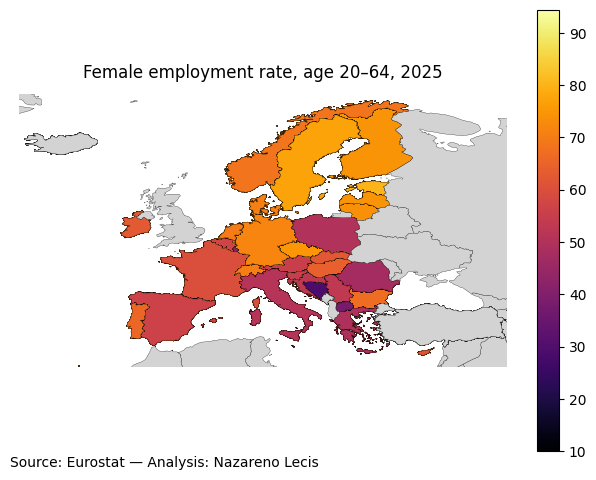

In [2]:
# Europe map – Female employment rate, age 20–64, latest year
# Requirements: pip install requests pandas pyjstat geopandas matplotlib

import re
import requests
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from pyjstat import pyjstat

API_URL = "https://ec.europa.eu/eurostat/api/dissemination/sdmx/2.1/data/lfsi_emp_a"
GISCO_URL = "https://gisco-services.ec.europa.eu/distribution/v2/countries/geojson/CNTR_RG_20M_2024_4326.geojson"

# --------- 1) Eurostat: females aged 20–64, percentage unit, latest year ----------
params = {
    "format": "JSON",
    "startPeriod": "2015",
    "sex": "F",
    "age": "Y20-64"
}

r = requests.get(API_URL, params=params, timeout=90)
r.raise_for_status()

tables = pyjstat.from_json_stat(r.json())
if not tables:
    raise RuntimeError("No table returned by the Eurostat API.")

df = tables[0].rename(columns=str)

col_indicator = "Employment indicator"
col_unit = "Unit of measure"
col_geo = "Geopolitical entity (reporting)"
col_time = "Time"
col_value = "value"

def ci(s, pat):
    return bool(re.search(pat, s or "", re.IGNORECASE))

# Indicator, LFS concept, and percentage unit
mask_indicator = df[col_indicator].apply(
    lambda s: ci(s, r"Total employment\s*\(resident population concept\s*-\s*LFS\)")
    or ci(s, r"\bEmployment rate\b")
)
mask_unit = df[col_unit].apply(lambda s: ci(s, r"percent|%"))

df = df[mask_indicator & mask_unit].copy()
if df.empty:
    raise RuntimeError("Empty filter: employment indicator or percentage unit not found.")

# Latest available year
def to_year(x):
    s = str(x)
    return int(s[:4]) if s[:4].isdigit() else None

df["year"] = df[col_time].map(to_year)
last_year = int(df["year"].dropna().max())

# Keep only the latest year
dfy = df[df["year"] == last_year][[col_geo, col_value]].copy()
dfy = dfy.rename(columns={
    col_geo: "geo_name",
    col_value: "female_emp_rate_20_64"
})
dfy["female_emp_rate_20_64"] = pd.to_numeric(dfy["female_emp_rate_20_64"], errors="coerce")

# Remove aggregates, EU and euro area
AGG_PATTERNS = [r"European Union", r"Euro area", r"countries\s*\(from"]
dfy = dfy[
    ~dfy["geo_name"].apply(lambda s: any(re.search(p, s) for p in AGG_PATTERNS))
].copy()

# --------- 2) GISCO: load geometries and join by country name ----------
gdf = gpd.read_file(GISCO_URL)

if "NAME_ENGL" not in gdf.columns:
    raise RuntimeError(f"Column 'NAME_ENGL' not found in GISCO. Columns: {list(gdf.columns)}")

merged = gdf[["NAME_ENGL", "geometry"]].merge(
    dfy,
    left_on="NAME_ENGL",
    right_on="geo_name",
    how="left"
)

# Do not colour Turkey
merged.loc[
    merged["NAME_ENGL"].isin(["Turkey", "Türkiye"]),
    "female_emp_rate_20_64"
] = None

# --------- 3) Plot: Europe zoom and inferno colour map ----------
plt.figure(figsize=(9, 7))

ax = merged.plot(
    column="female_emp_rate_20_64",
    cmap="inferno",
    legend=True,
    edgecolor="black",
    linewidth=0.2,
    missing_kwds={"color": "lightgrey", "label": "No data"}
)

# Europe limits
ax.set_xlim(-25, 45)
ax.set_ylim(33, 72)
ax.set_axis_off()

# Title
plt.title(f"Female employment rate, age 20–64, {last_year}", pad=12)

# Source and credit
plt.figtext(
    0.01,
    0.01,
    "Source: Eurostat — Analysis: Nazareno Lecis",
    ha="left",
    va="bottom"
)

plt.tight_layout()
plt.show()

# Optional: save figure
# plt.savefig(
#     f"female_emp_rate_{last_year}_europe_map.png",
#     dpi=300,
#     bbox_inches="tight"
# )

## Output

The map visualises cross-country differences in female employment rates and includes the data source and selected year directly in the figure.